In [354]:
import numpy as np
from scipy.sparse.linalg import expm, expm_multiply
from scipy.linalg import ishermitian
import matplotlib.pyplot as plt

from qiskit import QuantumCircuit
from utils import *

In [762]:
N = 64
R = 1
h = R / (N-1)
qubits = 2 * N + 1
T = 1
num_times = 16

In [763]:
x_vals = np.linspace(0, R, N)
t_vals = np.linspace(0, T, num_times)

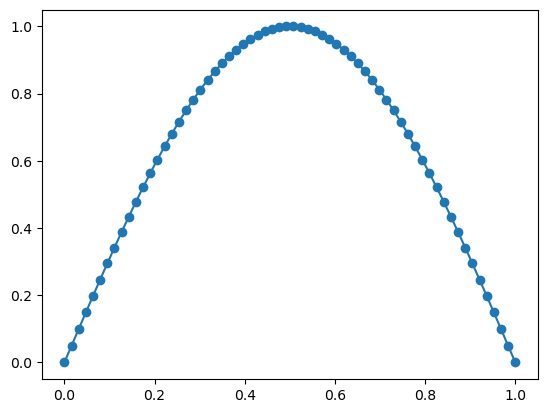

In [764]:
psi_0 = np.zeros(qubits)
psi_0[:N] = np.sin((np.pi * x_vals))

plt.plot(x_vals, psi_0[:N], '-o')
plt.show()

In [765]:
# B = np.zeros(N,N-1)
# for i in range(N-1):
#     B[i,i] = 1
#     B[i+1,i] = -1

B = np.zeros((N,N+1))
B[0,0] = 1
B[-1,-1] = 1
for i in np.arange(1,N):
    B[i-1,i] = 1
    B[i,i] = -1

B /= h


In [766]:
H = np.block([[np.zeros((N,N)), np.conj(B)],[B.T, np.zeros((N+1,N+1))]])

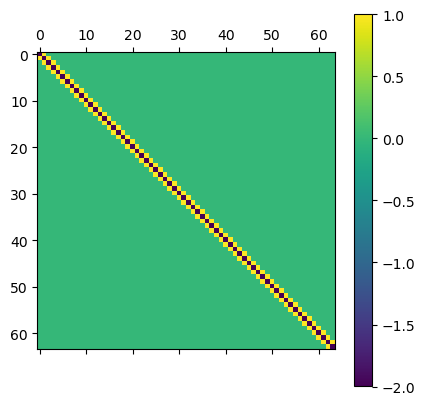

In [767]:
plt.matshow((-H @ H)[:N,:N] * h**2)
plt.colorbar()
plt.show()

In [768]:

psi = expm_multiply(-1j * H, psi_0, start=0, stop=T, num=num_times)

In [769]:
dist = np.abs(psi[:,:N]) ** 2

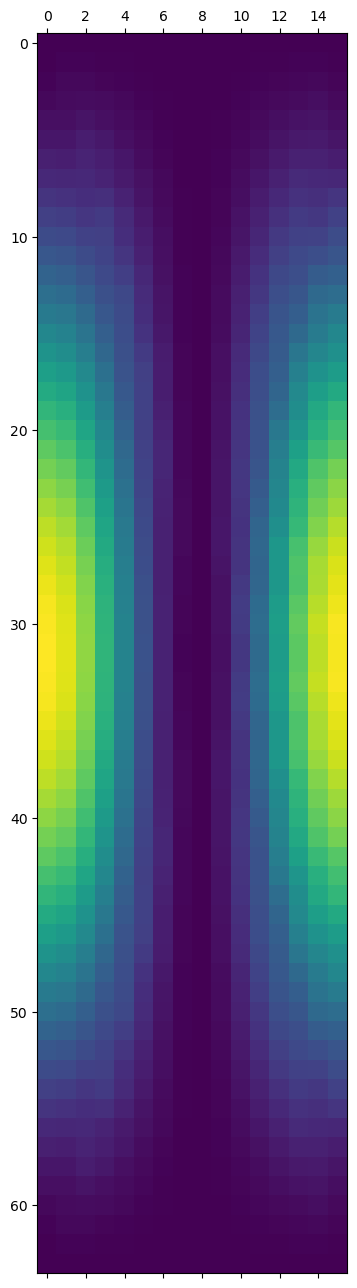

In [770]:
plt.matshow(dist.T)

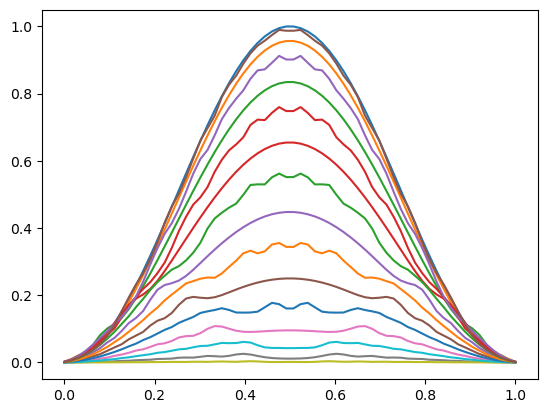

In [771]:
for i in range(num_times):
    plt.plot(x_vals, dist[i], label="i")

plt.show()

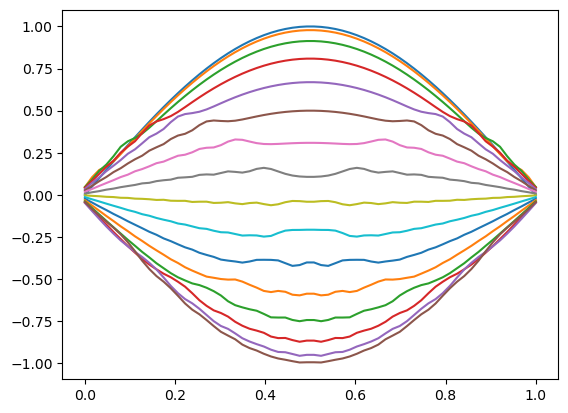

In [772]:
for i in range(num_times):
    plt.plot(x_vals, psi[i,:N].real, label="i")

plt.show()

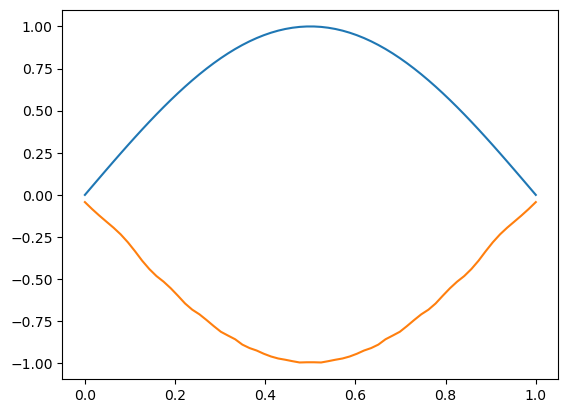

In [773]:

plt.plot(x_vals, psi[0,:N].real, label="start")
plt.plot(x_vals, psi[-1,:N].real, label="end")

plt.show()